In [2]:
import numpy as np
import string
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from astropy.wcs import WCS
import astropy.units as u
from astropy.io import fits
from astropy.wcs.utils import skycoord_to_pixel
from astropy.wcs.utils import pixel_to_skycoord
from astropy.coordinates import SkyCoord
from matplotlib.patches import Ellipse
from astropy.stats import mad_std
import matplotlib as mpl

In [3]:
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # or "Computer Modern"
    "font.size": 14,

    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,

    "mathtext.fontset": "cm",  # Computer Modern for LaTeX math
})

# Set Definitions

In [4]:
def plot_contours(data_array, color, sigma_m0, sigma_min, sigma_max, sigma_step):
    sigma_levels = np.arange(sigma_min, sigma_max + sigma_step, sigma_step)
    levels = sigma_m0 * sigma_levels

    return ax.contour(
        data_array,
        levels=levels,
        colors=color,
        linewidths=0.5,
        origin='lower',
        extent=[
            ra_offsets.min(), ra_offsets.max(),
            dec_offsets.min(), dec_offsets.max()
        ],
    )


def beam(beam_minor, beam_major, beam_pa, beam_position):
    # Set beam location
    beam_x = ra_offsets.min() + beam_position + 1
    beam_y = dec_offsets.min() + beam_position

    # Create the beam ellipse
    return Ellipse(
        (beam_x, beam_y),
        width=beam_major,
        height=beam_minor,
        angle=beam_pa,
        edgecolor='black',
        facecolor='black',
        alpha=0.7,
        zorder=10
    )


# Find Beam Values

In [5]:
# Load the FITS file
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/C18O/HOPS164_C18O_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/13CO/HOPS164_13CO_Tp12m7m_Combine_pbcor_masked.fits'
fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/CO/HOPS164_CO_Tp12m7m_Combine_pbcor_masked.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_cont_robust0.5.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/Continuum/HOPS-164_Continuum_natural_thres0.4mJy.pbcor.fits'
# fits_file = '/Users/ivarismartinez/Desktop/Research/REU23/CARMA/CARMA_NRO_Orion_12CO_HOPS-164_cut.fits'

hdu = fits.open(fits_file)[0]  # Open the primary HDU
wcs = WCS(hdu.header)          # Extract WCS projection

header = hdu.header

# Extract beam parameters and convert degrees to arcminutes
bmaj = (header.get('BMAJ', 0) * u.deg).to(u.arcmin)
bmin = (header.get('BMIN', 0) * u.deg).to(u.arcmin)
bpa  = header.get('BPA', 0)         # position angle in degrees

print(f"Beam major axis: {bmaj:.3f}'")
print(f"Beam minor axis: {bmin:.3f}'")
print(f"Beam position angle: {bpa:.2f}°")

Beam major axis: 0.021 arcmin'
Beam minor axis: 0.016 arcmin'
Beam position angle: 84.20°


# H2CO

# Read Cube and Find RMS Value

In [6]:
cube_H2CO=SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/H2CO/HOPS164_H2CO_Tp12m7m_Combine_pbcor_masked.fits')
cube_H2CO = cube_H2CO.to(u.K).with_spectral_unit(u.km/u.s)

In [7]:
sigma_m5_H2CO = 0.11

# Set Offset

In [8]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.540s", "-6d37m10.75s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube_H2CO.hdu.data

# Convert pixel grid to world coordinates
nx = cube_H2CO.shape[1]
ny = cube_H2CO.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_H2CO.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_H2CO.wcs.celestial)

# H2CO Channel Maps

0.030592944485098854 km / s
0.030592944485098854 km / s
0.030592944485098854 km / s
0.02916922806140933 km / s
0.030592944485098528 km / s
0.030592944485098854 km / s
0.030592944485098528 km / s
0.030592944485098205 km / s
0.030592944485098854 km / s


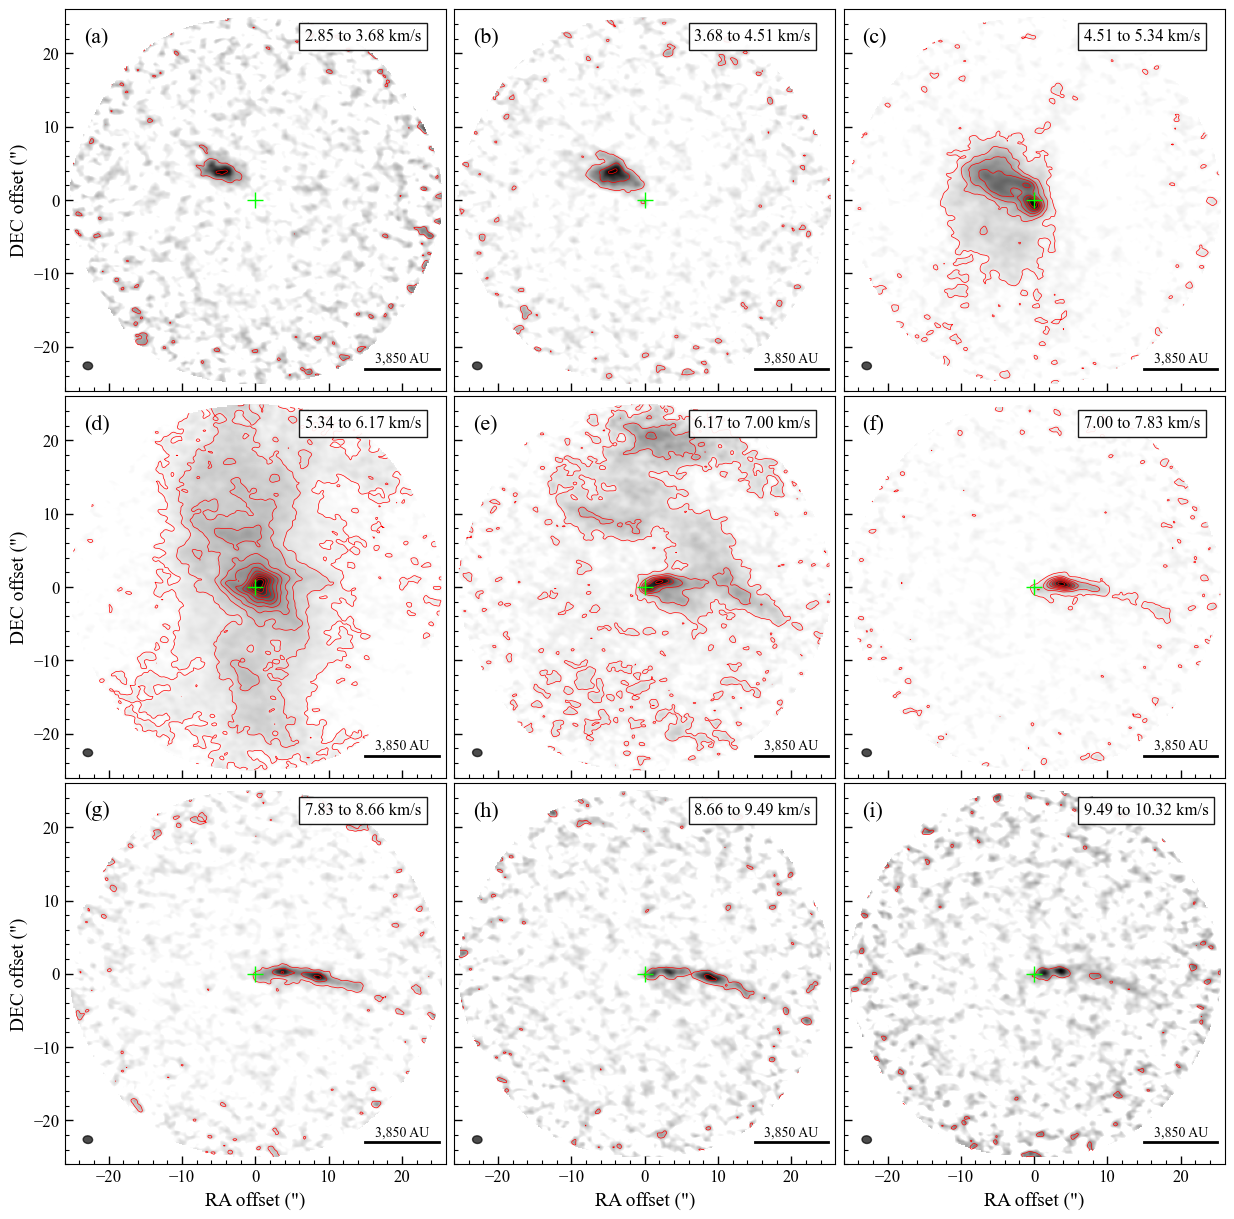

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(2.85, 10.41, 0.83)

for idx, v in enumerate(vel_bins[:-1]): 
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_H2CO = cube_H2CO.spectral_slab(v_start, v_end)
    moment0_H2CO = slab_H2CO.moment0().value

    # Finding RMS
    dv = np.abs(np.diff(slab_H2CO.spectral_axis)[0])
    N = slab_H2CO.shape[0]
    sigma_H2CO = sigma_m5_H2CO * np.sqrt(N) * dv
    print(sigma_H2CO)

    # Plot the moment 0 map
    im = ax.imshow(moment0_H2CO, cmap='binary', origin='lower', vmin=0, extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()])
    
    label = string.ascii_lowercase[idx] 
    ax.text(0.05, 0.955, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    plot_contours(moment0_H2CO, 'red', sigma_H2CO, sigma_min=5, sigma_max=100, sigma_step=10)
   
    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.63, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    # Add beam
    beam_H2CO = beam(1.29, 1.04, 83.63, 15)
    ax.add_patch(beam_H2CO)

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 41    # 5" from left
    y_start = ax.get_ylim()[0] + 3    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)


    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (")')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (")')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

plt.rcParams['font.family'] = 'serif'  # Options: 'serif', 'sans-serif', 'monospace', etc.
plt.rcParams['font.serif'] = ['Times New Roman']  # Or any font you have installed

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_H2CO_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_H2CO_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Read Cube and Find RMS Value

In [10]:
# cube_N2Dp =SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_Tp12m7m_large_Combine_pbcor.fits')
# cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

cube_N2Dp = SpectralCube.read('/Users/ivarismartinez/Desktop/Research/REU23/ALMA/HOPS164/N2Dp/HOPS164_N2Dp_large_sm_reb.fits')
cube_N2Dp = cube_N2Dp.to(u.K).with_spectral_unit(u.km/u.s)

In [11]:
sigma_m5_N2Dp = 0.06 # large_sm_reb

# sigma_m5_N2Dp = 0.16 # large_combine

# Set Offset

In [12]:
# Coordinates that APPEAR at the center of the protostar in ALMA data
marker_coord = SkyCoord("5h37m00.425s", "-6d37m10.89s", frame='icrs')

# Create a sky offset frame centered on the marker
offset_frame = marker_coord.skyoffset_frame()

# Transform it to the same offset frame as your image
marker_offset = marker_coord.transform_to(offset_frame)

# Access robust data
data_robust = cube_N2Dp.hdu.data

# Convert pixel grid to world coordinates
nx = cube_N2Dp.shape[1]
ny = cube_N2Dp.shape[2]
y_pix, x_pix = np.mgrid[:ny, :nx]
sky = pixel_to_skycoord(x_pix, y_pix, cube_N2Dp.wcs.celestial)

# Convert sky coordinates to offset frame
offset_coords = sky.transform_to(offset_frame)
ra_offsets = -offset_coords.lon.arcsec
dec_offsets = offset_coords.lat.arcsec

x_marker, y_marker = skycoord_to_pixel(marker_coord, cube_N2Dp.wcs.celestial)

# N2D+ Channel Maps

0.008221033673439758 km / s
0.008221033673439758 km / s
0.008221033673439758 km / s
0.008221033673439758 km / s
0.006712445886055267 km / s
0.008221033673439758 km / s
0.008221033673439758 km / s
0.008221033673439758 km / s
0.008221033673439758 km / s


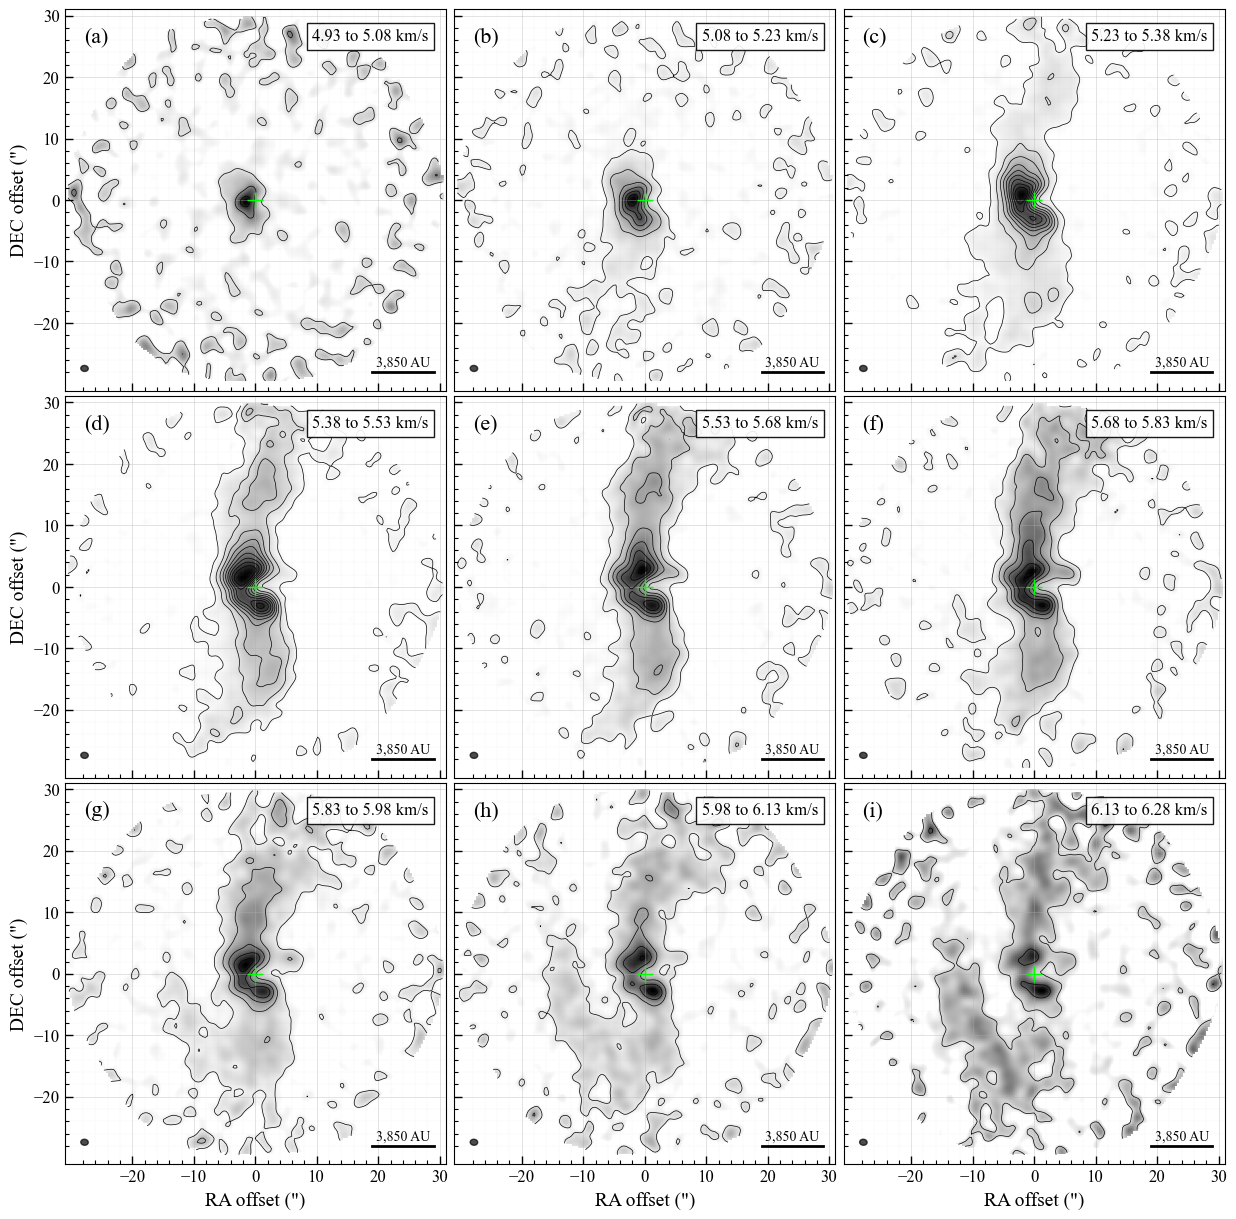

In [13]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(4.93, 6.36, 0.15)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_N2Dp = cube_N2Dp.spectral_slab(v_start, v_end)
    moment0_N2Dp = slab_N2Dp.moment0().value

    # Finding RMS
    dv = np.abs(np.diff(slab_N2Dp.spectral_axis)[0])
    N = slab_N2Dp.shape[0]
    sigma_N2Dp = sigma_m5_N2Dp * np.sqrt(N) * dv
    print(sigma_N2Dp)

    # Plot the moment 0 map
    im = ax.imshow(moment0_N2Dp, cmap='binary', origin='lower', vmin=0, extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()])

    label = string.ascii_lowercase[idx] 
    ax.text(0.05, 0.955, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Plot contours with proper data handling
    plot_contours(moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)
    
    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.65, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    beam_N2Dp = beam(1.22, 0.98, 84.98, 10) #beam arcseconds times pixel arcseconds for the fits file
    ax.add_patch(beam_N2Dp)

    ax.set_xlim(-31, 31) 
    ax.set_ylim(-31, 31)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 31, 10))
    ax.set_yticks(np.arange(-20, 31, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-28, 30, 2), minor=True)
    ax.set_yticks(np.arange(-28, 30, 2), minor=True)

        # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 50    # 5" from left
    y_start = ax.get_ylim()[0] + 3    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (")')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (")')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

    ax.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.5)
    ax.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.3)

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# plt.savefig("HOPS164_N2Dp_channel_maps.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_N2Dp_channel_maps.png", format="png", dpi=300, bbox_inches="tight")

plt.show()

# Comparison

0.013044875359300857 km / s
0.008221033673439758 km / s
0.015976644194246405 km / s
0.008221033673439758 km / s
0.015976644194246235 km / s
0.008221033673439758 km / s
0.015976644194246575 km / s
0.008221033673439758 km / s
0.015976644194246235 km / s
0.006712445886055267 km / s
0.013044875359300857 km / s
0.008221033673439758 km / s
0.015976644194246405 km / s
0.008221033673439758 km / s
0.015976644194246405 km / s
0.008221033673439758 km / s
0.015976644194246235 km / s
0.008221033673439758 km / s


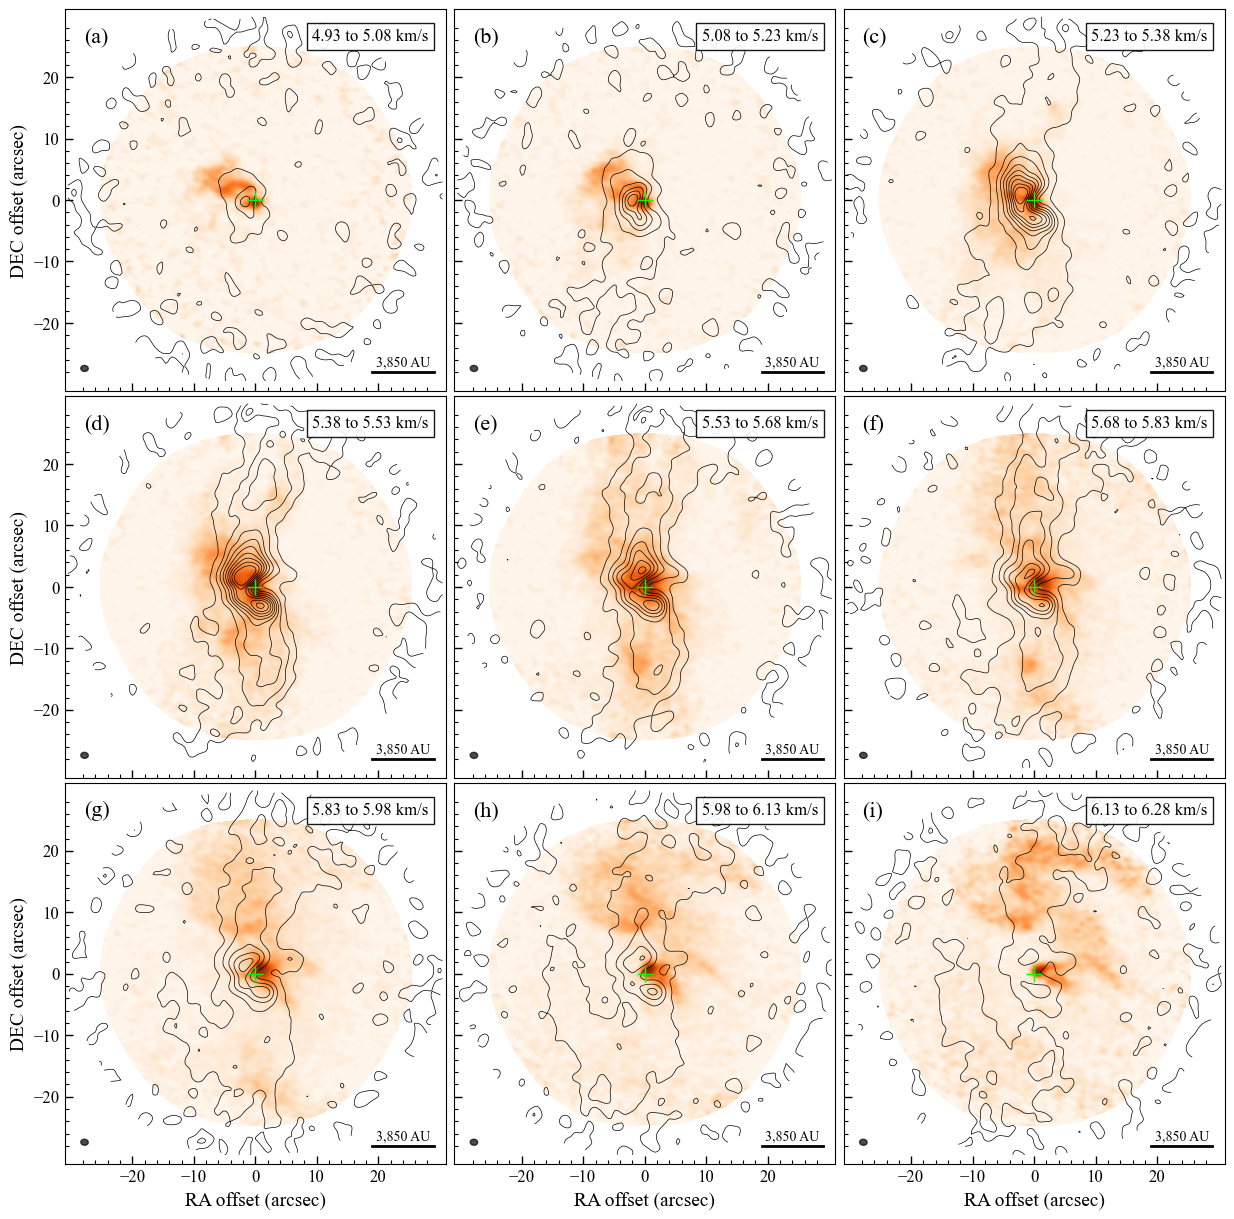

In [16]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

vel_bins = np.arange(4.93, 6.36, 0.15)

for idx, v in enumerate(vel_bins[:-1]):  
    row = idx // 3  # Calculate the row index (0 to 4)
    col = idx % 3   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    v_start = v * u.km / u.s
    v_end = vel_bins[idx + 1] * u.km / u.s

    slab_H2CO = cube_H2CO.spectral_slab(v_start, v_end)
    moment0_H2CO = slab_H2CO.moment0().value

    slab_N2Dp = cube_N2Dp.spectral_slab(v_start, v_end)
    moment0_N2Dp = slab_N2Dp.moment0().value

    # Finding RMS
    dv = np.abs(np.diff(slab_H2CO.spectral_axis)[0])
    N = slab_H2CO.shape[0]
    sigma_H2CO = sigma_m5_H2CO * np.sqrt(N) * dv
    print(sigma_H2CO)

    # Finding RMS
    dv = np.abs(np.diff(slab_N2Dp.spectral_axis)[0])
    N = slab_N2Dp.shape[0]
    sigma_N2Dp = sigma_m5_N2Dp * np.sqrt(N) * dv
    print(sigma_N2Dp)

    # Plot the moment 0 map
    im = ax.imshow(moment0_H2CO, cmap='Oranges', origin='lower', vmin=0, extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()])

    label = string.ascii_lowercase[idx] 
    ax.text(0.05, 0.955, f"({label})", transform=ax.transAxes,
        fontsize=16, va='top', ha='left')

    # Plot contours with proper data handling
    # plot_contours(moment0_H2CO, 'red', sigma_H2CO, sigma_min=5, sigma_max=100, sigma_step=10)
    plot_contours(moment0_N2Dp, 'black', sigma_N2Dp, sigma_min=3, sigma_max=80, sigma_step=10)
    
    # Get velocity for the current slice
    velocity1 = v_start.value
    velocity2 = v_end.value

    # Add velocity label in the top left of the subplot
    ax.text(0.65, 0.95, f"{velocity1:.2f} to {velocity2:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))
    
    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    beam_N2Dp = beam(1.22, 0.98, 84.98, 10) #beam arcseconds times pixel arcseconds for the fits file
    ax.add_patch(beam_N2Dp)

    ax.set_xlim(-31, 31) 
    ax.set_ylim(-31, 31)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 30, 10))
    ax.set_yticks(np.arange(-20, 30, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-28, 30, 2), minor=True)
    ax.set_yticks(np.arange(-28, 30, 2), minor=True)

        # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 50    # 5" from left
    y_start = ax.get_ylim()[0] + 3    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

    # Only show RA labels on the bottom row
    if row < 2:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (arcsec)')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (arcsec)')

    # Hide tick labels for non-edge plots
    if row < 2:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

plt.savefig("HOPS164_N2Dp_over_H2CO_channel_map_comparison_comps.pdf", dpi=300, bbox_inches="tight")
plt.savefig("HOPS164_N2Dp_over_H2CO_channel_map_comparison_comps.png", dpi=300, bbox_inches="tight")

plt.show()

# All Channels

NameError: name 'sigma_m0_N2Dp' is not defined

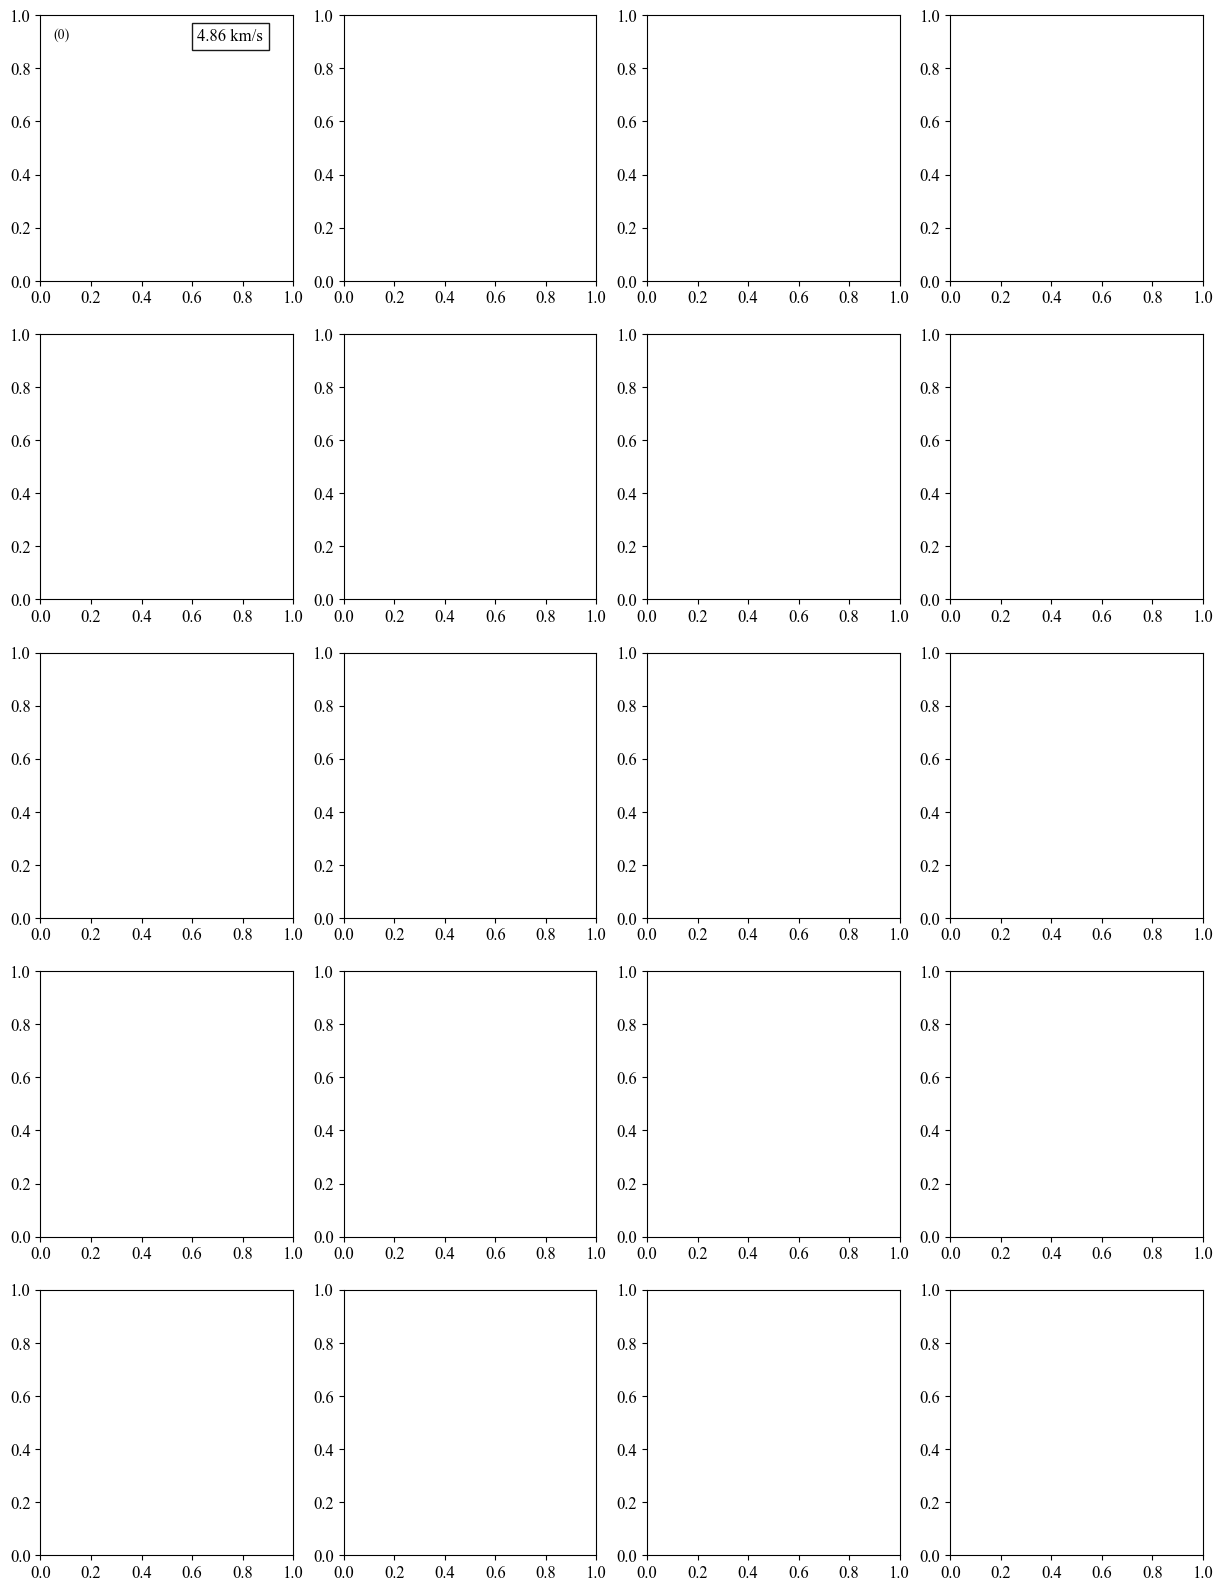

In [15]:
fig, axes = plt.subplots(5, 4, figsize=(15, 20))

for idx, i in enumerate(range(119, 139, 1)):  
    row = idx // 4  # Calculate the row index (0 to 4)
    col = idx % 4   # Calculate the column index (0 to 4)
    ax = axes[row, col]

    # Plot the moment 0 map
    # im = ax.imshow(cube_N2Dp[i].value, cmap='Oranges', origin='lower', vmin=0, extent=[
    #     ra_offsets.min(), ra_offsets.max(),
    #     dec_offsets.min(), dec_offsets.max()])
    
    ax.text(0.05, 0.955, f"({idx})",
        transform=ax.transAxes,
        fontsize=10, va='top', ha='left')

    # Get velocity for the current slice
    velocity = cube_N2Dp.spectral_axis[i].to(u.km / u.s).value

    # Find channel
    target_velocity = velocity * u.km / u.s
    diff = np.abs(cube_H2CO.spectral_axis - target_velocity)
    channel = np.argmin(diff)

    # Add velocity label in the top left of the subplot
    ax.text(0.62, 0.95, f"{velocity:.2f} km/s", transform=ax.transAxes, fontsize=12, 
        verticalalignment='top', bbox=dict(facecolor='white', alpha=0.9))

    # Plot contours with proper data handling
    # plot_contours(cube_H2CO[channel].value, 'black', sigma_m0_H2CO, sigma_min=5, sigma_max=39, sigma_step=4)
    plot_contours(cube_N2Dp[i].value, 'black', sigma_m0_N2Dp, sigma_min=5, sigma_max=81, sigma_step=10)

    im = ax.imshow(cube_H2CO[channel].value, cmap='Oranges', origin='lower', vmin=0, extent=[
        ra_offsets.min(), ra_offsets.max(),
        dec_offsets.min(), dec_offsets.max()])

    # Add a star marker at the specified coordinates
    ax.plot(0, 0, marker='+', color='lime', markersize=12)

    # Add beam
    # beam_13CO = beam(1.29, 1.03, 84.42, 15)
    # ax.add_patch(beam_13CO)

    ax.set_xlim(-26, 26) 
    ax.set_ylim(-26, 26)

    # Set major ticks every 10 arcseconds
    ax.set_xticks(np.arange(-20, 26, 10))
    ax.set_yticks(np.arange(-20, 26, 10))

    # Set minor ticks every 2 arcseconds
    ax.set_xticks(np.arange(-26, 26, 2), minor=True)
    ax.set_yticks(np.arange(-26, 26, 2), minor=True)

    # Customize tick appearance
    ax.tick_params(axis='both', which='major', length=6, width=1, direction='in')
    ax.tick_params(axis='both', which='minor', length=3, width=0.8, direction='in')

    # Set starting point for the scale bar (in arcseconds)
    x_start = ax.get_xlim()[0] + 41    # 5" from left
    y_start = ax.get_ylim()[0] + 3    # 5" from bottom

    # Length of the bar in arcseconds
    scale_bar_length = 10  # arcseconds

    # Plot the scale bar
    ax.plot([x_start, x_start + scale_bar_length], [y_start, y_start], color='black', linewidth=2)

    # Label it
    ax.text(x_start + scale_bar_length / 2, y_start + 0.5, "3,850 AU",
        color='black', ha='center', va='bottom', fontsize=10)

    # Only show RA labels on the bottom row
    if row < 4:
        ax.set_xlabel('')
    else:
        ax.set_xlabel('RA offset (")')

    # Only show DEC labels on the left column
    if col > 0:
        ax.set_ylabel('')
    else:
        ax.set_ylabel('DEC offset (")')

    # Hide tick labels for non-edge plots
    if row < 4:
        ax.tick_params(axis='x', labelbottom=False)
    if col > 0:
        ax.tick_params(axis='y', labelleft=False)

    # plt.colorbar(im, ax=ax, label='Brightness Temperature [K]')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.015, hspace=0.015)

# fig.text(0.5, 0.005, "Black contours: 12CO     |     Orange background: C18O", ha='center', va='bottom', fontsize=16)

# plt.savefig("HOPS164_12CO_over_13CO_channel_map_comparison.pdf", format="pdf", dpi=300, bbox_inches="tight")
# plt.savefig("HOPS164_12CO_over_13CO_channel_map_comparison.png", format="png", dpi=300, bbox_inches="tight")

plt.show()